In [1]:
import matplotlib.pyplot as plt 
import matplotlib.image as mpimg   
import numpy as np

Implementación del algoritmo de White Patch
- Gráfico imagenes de prueba:

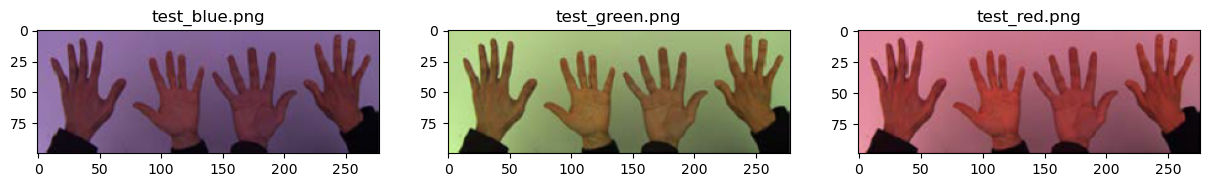

In [10]:
images_test_path = "imgs/"
images_test = ["test_blue.png", "test_green.png", "test_red.png"]
fig, axs = plt.subplots(nrows=1, ncols=len(images_test))
fig.set_size_inches(15, 10)
for ax, img_file in zip(axs, images_test):
    raw_img = mpimg.imread(images_test_path + img_file)
    ax.imshow(raw_img)
    ax.set_title(img_file)

Algoritmo de white patch, pasando como parámetros una img y el percentil

In [7]:

def white_patch(image: np.ndarray, percentile: int = 100) -> np.ndarray:

    # Convierto la img a punto flotante
    image = image.astype(np.float32)

    # Calcular percentil por canal (R, G, B)
    ilum = np.percentile(image.reshape(-1, 3), percentile, axis=0)

    # Evito div por cero
    ilum[ilum == 0] = 1.0

    # Normalizo
    new_img = image / ilum

    #clip para forzar valores entre 0 y 1
    return np.clip(new_img, 0, 1)


Uso el algoritmo W-P sobre las imagenes TEST

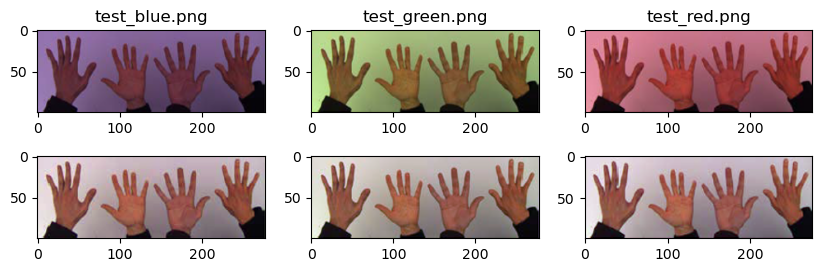

In [11]:
fig, axs = plt.subplots(nrows=2, ncols=len(images_test))
fig.set_size_inches(10, 3)
for ax_raw, ax_wp, img_file in zip(axs[:][0], axs[:][1], images_test):
    raw_img = mpimg.imread(images_test_path + img_file)[:,:,:3]
    ax_raw.imshow(raw_img)
    ax_raw.set_title(img_file)
    ax_wp.imshow(white_patch(raw_img))

Genero W-P para las demás imágenes del set

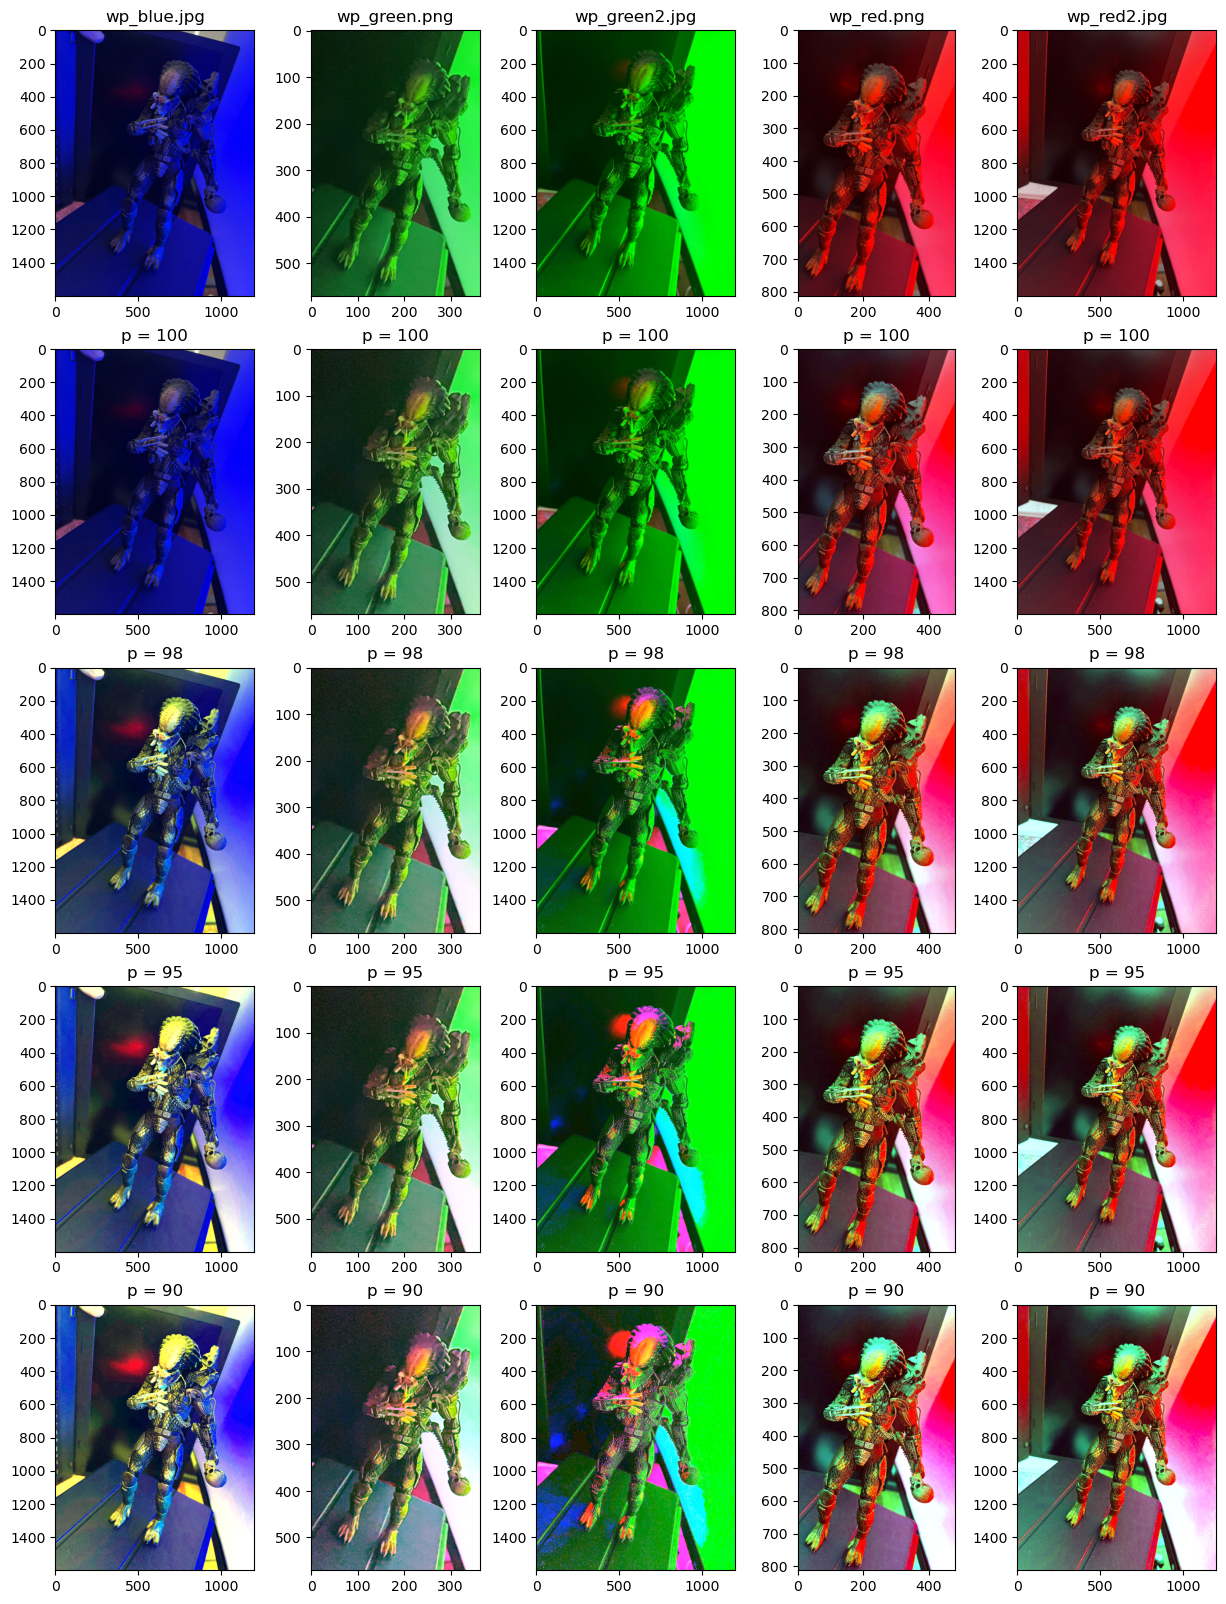

In [12]:

BASE_DIR = "imgs/"

IMAGE_LIST = (
    "wp_blue.jpg",
    "wp_green.png",
    "wp_green2.jpg",
    "wp_red.png",
    "wp_red2.jpg",
)
# Seteo estos percentiles de prueba
PERC_LEVELS = [100, 98, 95, 90]

rows = len(PERC_LEVELS) + 1
cols = len(IMAGE_LIST)

figure, grid = plt.subplots(nrows=rows, ncols=cols)
figure.set_size_inches(15, 20)

# --- Primera fila: imágenes originales ---
for axis, name in zip(grid[0], IMAGE_LIST):
    img = mpimg.imread(f"{BASE_DIR}{name}")
    axis.imshow(img)
    axis.set_title(name)

# --- Resto de filas: White Patch con distintos percentiles ---
for row_idx, p in enumerate(PERC_LEVELS):
    for axis, name in zip(grid[row_idx + 1], IMAGE_LIST):
        img = mpimg.imread(BASE_DIR + name)

        # Normalización según formato
        if name.lower().endswith(".jpg"):
            img = img[..., :3] / 255.0
        else:
            img = img[..., :3]

        corrected = white_patch(img, percentile=p)
        axis.imshow(corrected)
        axis.set_title(f"p = {p}")


Conclusiones:
- Se observa que al utilizar un percentil de 100 (valor por defecto), el algoritmo en la mayoría de los casos no logra reconstruir correctamente la imagen. Esto se debe a que las imágenes analizadas presentan seguramente una saturación en algunos canales.
- Al reemplazar el máximo absoluto de cada canal por el percentil 98 o 95, el método resulta suficiente para obtener una recuperación visual.
- En cambio, al emplear percentiles más bajos como 90, la imagen obtenida muestra cambios profundos en sus colores.